In [1]:
import zipfile
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ZIP_DIR = Path("data/zips")
SYMBOL = "RADUSDT"

KLINES_COLUMNS = [
    "Open time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close time",
    "Quote asset volume",
    "Number of trades",
    "Taker buy base asset volume",
    "Taker buy quote asset volume",
    "Ignore",
]

# Load all monthly zips into one DataFrame
frames = []
for zp in sorted(ZIP_DIR.glob(f"{SYMBOL}-1m-2025-*.zip")):
    with zipfile.ZipFile(zp) as zf:
        with zf.open(zf.namelist()[0]) as f:
            df = pd.read_csv(f, header=None, names=KLINES_COLUMNS)
    # Binance 1m klines use microsecond timestamps
    df["time"] = pd.to_datetime(df["Open time"], unit="us", utc=True).dt.tz_convert(
        None
    )
    df["price"] = df["Open"].astype(float)
    frames.append(df[["time", "price"]])
    print(f"Loaded {zp.name}: {len(df)} rows")

data = pd.concat(frames, ignore_index=True).sort_values("time").reset_index(drop=True)
print(f"\nTotal: {len(data)} rows, {data['time'].min()} — {data['time'].max()}")

Loaded RADUSDT-1m-2025-01.zip: 44640 rows
Loaded RADUSDT-1m-2025-02.zip: 40320 rows
Loaded RADUSDT-1m-2025-03.zip: 44640 rows
Loaded RADUSDT-1m-2025-04.zip: 43200 rows
Loaded RADUSDT-1m-2025-05.zip: 44640 rows
Loaded RADUSDT-1m-2025-06.zip: 43200 rows
Loaded RADUSDT-1m-2025-07.zip: 44640 rows
Loaded RADUSDT-1m-2025-08.zip: 44640 rows
Loaded RADUSDT-1m-2025-09.zip: 43200 rows
Loaded RADUSDT-1m-2025-10.zip: 44640 rows
Loaded RADUSDT-1m-2025-11.zip: 43200 rows
Loaded RADUSDT-1m-2025-12.zip: 44640 rows

Total: 525600 rows, 2025-01-01 00:00:00 — 2025-12-31 23:59:00


In [ ]:
# Compute log-returns
data["log_ret"] = np.log(data["price"] / data["price"].shift(1))
data = data.dropna().reset_index(drop=True)

# Rolling window parameters
WINDOW = 1440  # 1440 min = 1 day

data["rolling_mu"] = data["log_ret"].rolling(WINDOW).mean() * WINDOW  # daily drift
data["rolling_sigma"] = data["log_ret"].rolling(WINDOW).std() * np.sqrt(
    WINDOW
)  # daily vol

print(f"Rolling window: {WINDOW} minutes")

Rolling window: 1440 minutes (1 day)


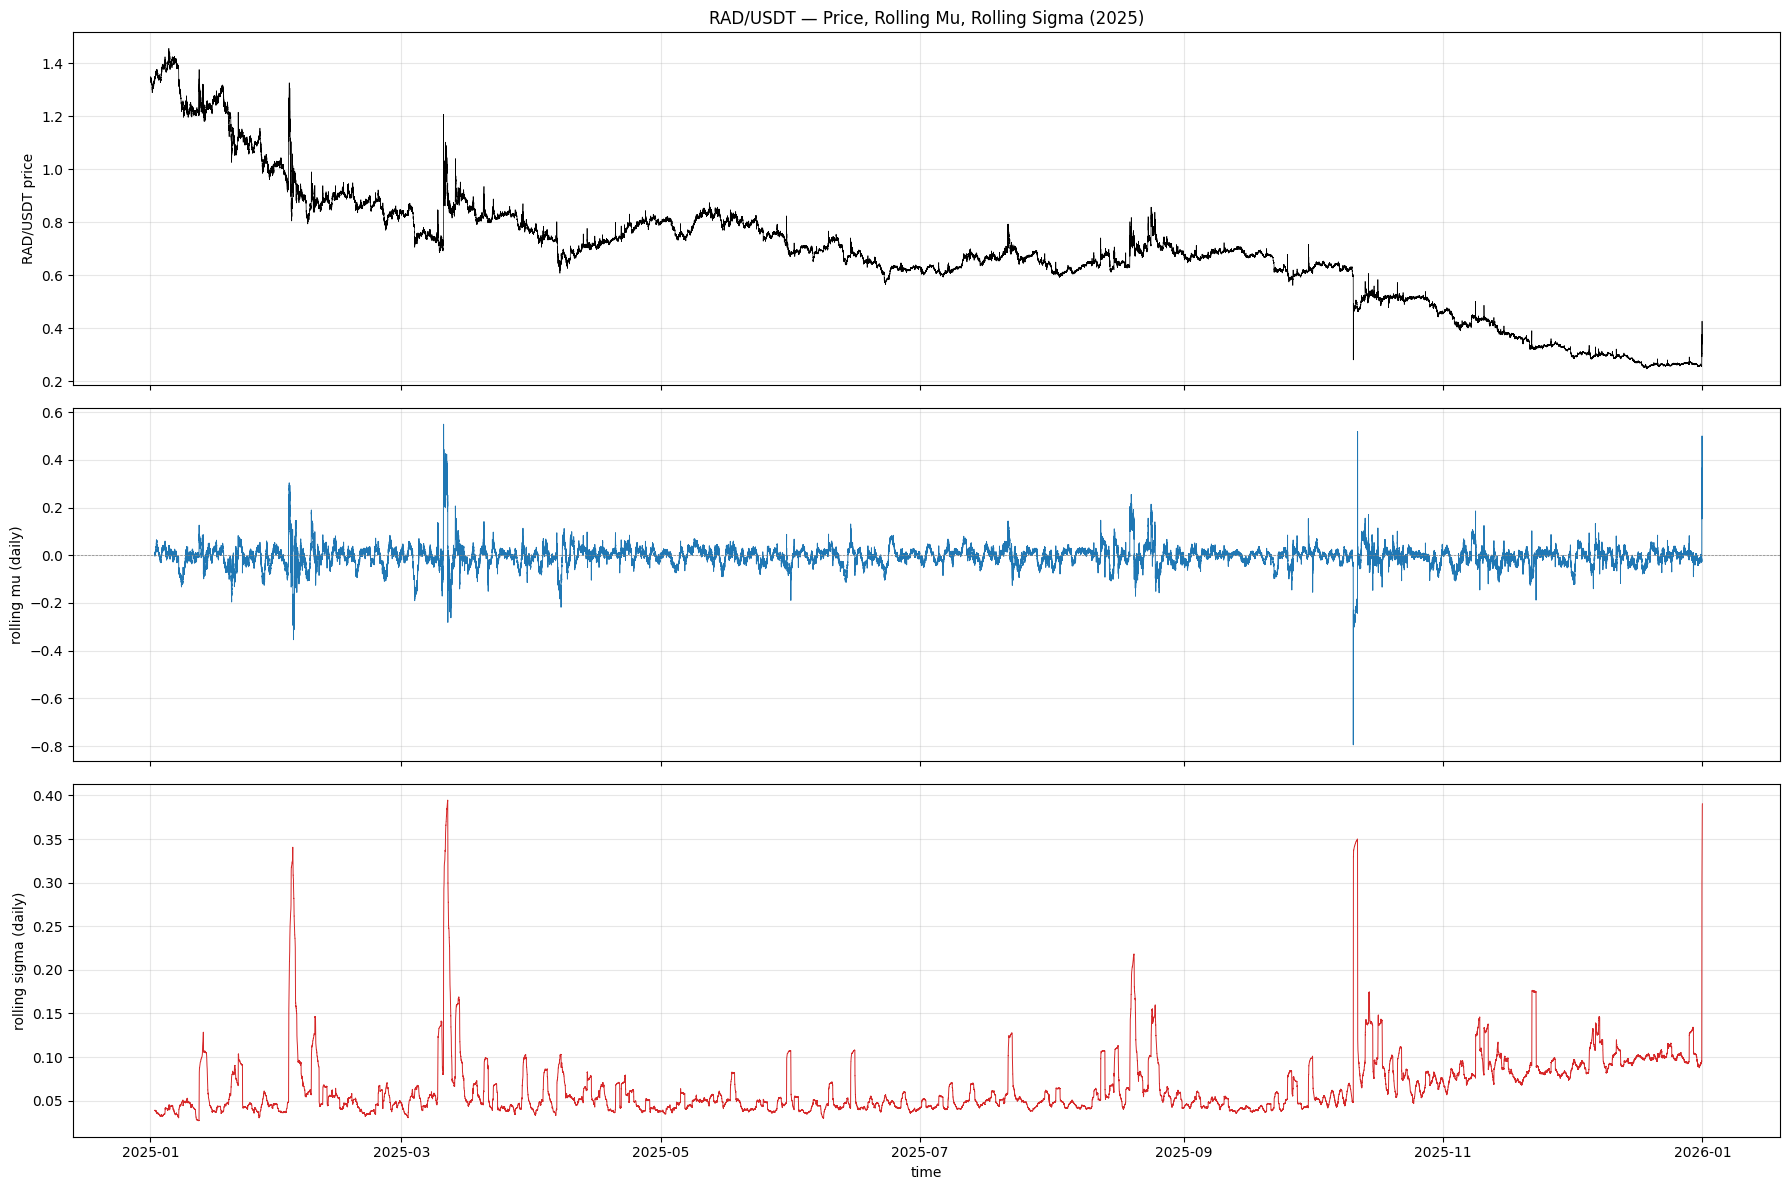

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Price
ax = axes[0]
ax.plot(data["time"], data["price"], linewidth=0.5, color="black")
ax.set_ylabel("RAD/USDT price")
ax.set_title("RAD/USDT — Price, Rolling Mu, Rolling Sigma (2025)")
ax.grid(True, alpha=0.3)

# Rolling mu (daily drift)
ax = axes[1]
ax.plot(data["time"], data["rolling_mu"], linewidth=0.7, color="tab:blue")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_ylabel("rolling mu (daily)")
ax.grid(True, alpha=0.3)

# Rolling sigma (daily vol)
ax = axes[2]
ax.plot(data["time"], data["rolling_sigma"], linewidth=0.7, color="tab:red")
ax.set_ylabel("rolling sigma (daily)")
ax.set_xlabel("time")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

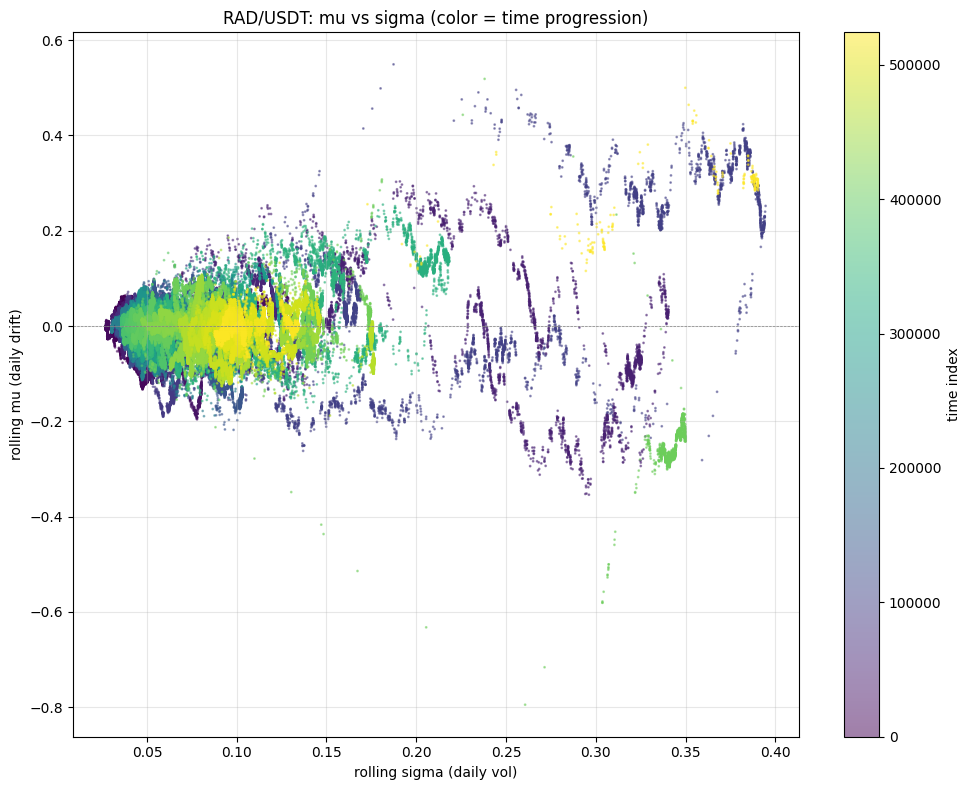

In [4]:
# Scatter: mu vs sigma colored by time — helps identify regimes
mask = data["rolling_mu"].notna()
colors = np.arange(mask.sum())

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    data.loc[mask, "rolling_sigma"],
    data.loc[mask, "rolling_mu"],
    c=colors,
    cmap="viridis",
    s=1,
    alpha=0.5,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("rolling sigma (daily vol)")
ax.set_ylabel("rolling mu (daily drift)")
ax.set_title("RAD/USDT: mu vs sigma (color = time progression)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("time index")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()